Objective

Given all concrete mixes in your dataset, identify those that satisfy:

High compressive strength (maximize)
Low material cost (minimize)
Low carbon emission (minimize)

This is called multi-objective optimization.


In [1]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
import os

In [10]:
# Load dataset containing strength, cost and carbon emission
df = pd.read_csv("../results/concrete_with_carbon.csv")

print("Dataset Shape:", df.shape)

df.head()

Dataset Shape: (1005, 11)


,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Strength,Material_Cost_INR,Carbon_Emission_kgCO2
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99,6822.10,502.4486
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89,6840.10,502.5686
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27,4977.55,317.1544
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05,4977.55,317.1544
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30,4094.48,197.6371


In [12]:
# Check Important Columns 
df[["Strength",
    "Material_Cost_INR",
    "Carbon_Emission_kgCO2"]].describe()

,Strength,Material_Cost_INR,Carbon_Emission_kgCO2
count,1005.000000,1005.000000,1005.000000
mean,35.250378,5370.601766,279.069509
std,16.284815,1102.919827,93.238065
min,2.330000,3342.000000,111.619600
25%,23.520000,4648.155000,198.852500
50%,33.800000,5097.530000,265.220130
75%,44.870000,5933.215000,332.055170
max,82.600000,10072.010000,542.513840


In [15]:
# Normalize Objectives
''' 
Strength → Higher is Better
Cost → Lower is Better
Carbon → Lower is Better
'''
scaler = MinMaxScaler()

df["Strength_Norm"] = scaler.fit_transform(df[["Strength"]])

df["Cost_Norm"] = scaler.fit_transform(df[["Material_Cost_INR"]])

df["Carbon_Norm"] = scaler.fit_transform(df[["Carbon_Emission_kgCO2"]])

df.head()

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Strength,Material_Cost_INR,Carbon_Emission_kgCO2,Strength_Norm,Cost_Norm,Carbon_Norm
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99,6822.10,502.4486,0.967485,0.517102,0.907018
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89,6840.10,502.5686,0.741996,0.519776,0.907297
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27,4977.55,317.1544,0.472655,0.243023,0.476996
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05,4977.55,317.1544,0.482372,0.243023,0.476996
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30,4094.48,197.6371,0.522860,0.111810,0.199626


In [17]:
# Convert Cost and Carbon into Benefit Scores
#Lower values are better, so invert them.

df["Cost_Score"] = 1 - df["Cost_Norm"]

df["Carbon_Score"] = 1 - df["Carbon_Norm"]

df.head()

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Strength,Material_Cost_INR,Carbon_Emission_kgCO2,Strength_Norm,Cost_Norm,Carbon_Norm,Cost_Score,Carbon_Score
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99,6822.10,502.4486,0.967485,0.517102,0.907018,0.482898,0.092982
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89,6840.10,502.5686,0.741996,0.519776,0.907297,0.480224,0.092703
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27,4977.55,317.1544,0.472655,0.243023,0.476996,0.756977,0.523004
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05,4977.55,317.1544,0.482372,0.243023,0.476996,0.756977,0.523004
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30,4094.48,197.6371,0.522860,0.111810,0.199626,0.888190,0.800374


In [18]:
# Calculate Optimization Score
''' 
Weights:
Strength = 50%
Cost = 25%
Carbon = 25%
'''
df["Optimization_Score"] = (
      0.50 * df["Strength_Norm"]
    + 0.25 * df["Cost_Score"]
    + 0.25 * df["Carbon_Score"]
)

df.head()

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Strength,Material_Cost_INR,Carbon_Emission_kgCO2,Strength_Norm,Cost_Norm,Carbon_Norm,Cost_Score,Carbon_Score,Optimization_Score
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99,6822.10,502.4486,0.967485,0.517102,0.907018,0.482898,0.092982,0.627712
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89,6840.10,502.5686,0.741996,0.519776,0.907297,0.480224,0.092703,0.514230
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27,4977.55,317.1544,0.472655,0.243023,0.476996,0.756977,0.523004,0.556323
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05,4977.55,317.1544,0.482372,0.243023,0.476996,0.756977,0.523004,0.561181
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30,4094.48,197.6371,0.522860,0.111810,0.199626,0.888190,0.800374,0.683571


In [19]:
# Rank Concrete Mixes
optimized_df = df.sort_values(
    by="Optimization_Score",
    ascending=False
)

optimized_df.reset_index(drop=True, inplace=True)

optimized_df.head(10)

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Strength,Material_Cost_INR,Carbon_Emission_kgCO2,Strength_Norm,Cost_Norm,Carbon_Norm,Cost_Score,Carbon_Score,Optimization_Score
0,315.0,137.0,0.0,145.0,5.9,1130.0,745.0,28,81.75,5904.750,314.52450,0.989411,0.380794,0.470893,0.619206,0.529107,0.781784
1,275.0,180.0,120.0,162.0,10.4,830.0,765.0,28,76.24,6134.600,290.16560,0.920767,0.414947,0.414362,0.585053,0.585638,0.753056
2,190.0,190.0,0.0,228.0,0.0,932.0,670.0,365,53.69,3984.800,191.75440,0.639841,0.095512,0.185973,0.904488,0.814027,0.749549
3,286.3,200.9,0.0,144.7,11.2,1004.6,803.7,91,76.80,6396.705,301.27151,0.927744,0.453893,0.440136,0.546107,0.559864,0.740365
4,167.0,75.4,167.0,164.0,7.9,1007.3,770.1,100,56.81,4914.760,185.53990,0.678709,0.233694,0.171551,0.766306,0.828449,0.738044
5,173.5,50.1,173.5,164.8,6.5,1006.2,793.5,100,56.06,4761.230,187.72624,0.669366,0.210881,0.176625,0.789119,0.823375,0.737807
6,323.7,282.8,0.0,183.8,10.3,942.7,659.9,56,80.20,6636.180,336.29584,0.970101,0.489476,0.521419,0.510524,0.478581,0.732327
7,190.0,190.0,0.0,228.0,0.0,932.0,670.0,270,50.66,3984.800,191.75440,0.602093,0.095512,0.185973,0.904488,0.814027,0.730675
8,250.0,180.0,95.0,159.0,9.5,860.0,800.0,28,67.87,5834.950,265.71270,0.816494,0.370423,0.357612,0.629577,0.642388,0.726238
9,165.0,128.5,132.1,175.1,8.1,1005.8,746.6,100,55.02,4986.515,185.80863,0.656410,0.244356,0.172175,0.755644,0.827825,0.724072


In [21]:
# Display Top 10 Recommended Mixes
top10 = optimized_df[[
    "Cement",
    "Blast Furnace Slag",
    "Fly Ash",
    "Water",
    "Superplasticizer",
    "Coarse Aggregate",
    "Fine Aggregate",
    "Age",
    "Strength",
    "Material_Cost_INR",
    "Carbon_Emission_kgCO2",
    "Optimization_Score"
]].head(10)

top10

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Strength,Material_Cost_INR,Carbon_Emission_kgCO2,Optimization_Score
0,315.0,137.0,0.0,145.0,5.9,1130.0,745.0,28,81.75,5904.750,314.52450,0.781784
1,275.0,180.0,120.0,162.0,10.4,830.0,765.0,28,76.24,6134.600,290.16560,0.753056
2,190.0,190.0,0.0,228.0,0.0,932.0,670.0,365,53.69,3984.800,191.75440,0.749549
3,286.3,200.9,0.0,144.7,11.2,1004.6,803.7,91,76.80,6396.705,301.27151,0.740365
4,167.0,75.4,167.0,164.0,7.9,1007.3,770.1,100,56.81,4914.760,185.53990,0.738044
5,173.5,50.1,173.5,164.8,6.5,1006.2,793.5,100,56.06,4761.230,187.72624,0.737807
6,323.7,282.8,0.0,183.8,10.3,942.7,659.9,56,80.20,6636.180,336.29584,0.732327
7,190.0,190.0,0.0,228.0,0.0,932.0,670.0,270,50.66,3984.800,191.75440,0.730675
8,250.0,180.0,95.0,159.0,9.5,860.0,800.0,28,67.87,5834.950,265.71270,0.726238
9,165.0,128.5,132.1,175.1,8.1,1005.8,746.6,100,55.02,4986.515,185.80863,0.724072


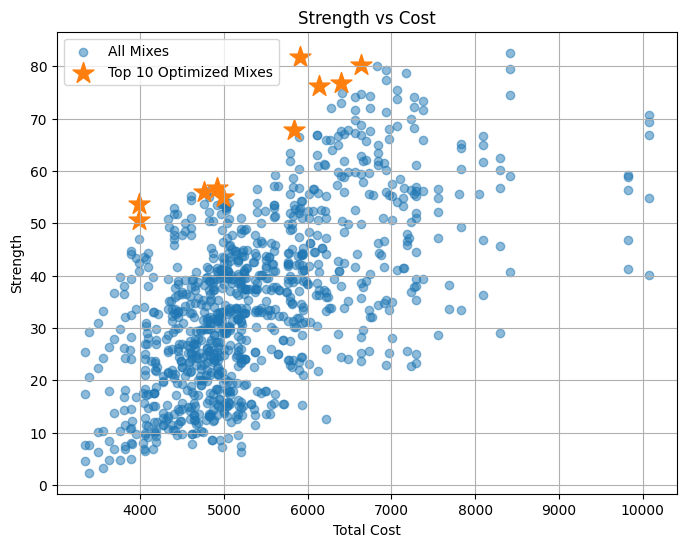

In [25]:
# Scatter Plot (Strength vs Cost)
plt.figure(figsize=(8,6))

plt.scatter(
    df["Material_Cost_INR"],
    df["Strength"],
    alpha=0.5,
    label="All Mixes"
)

plt.scatter(
    top10["Material_Cost_INR"],
    top10["Strength"],
    marker="*",
    s=250,
    label="Top 10 Optimized Mixes"
)

plt.xlabel("Total Cost")
plt.ylabel("Strength")
plt.title("Strength vs Cost")
plt.legend()
plt.grid(True)
plt.show()

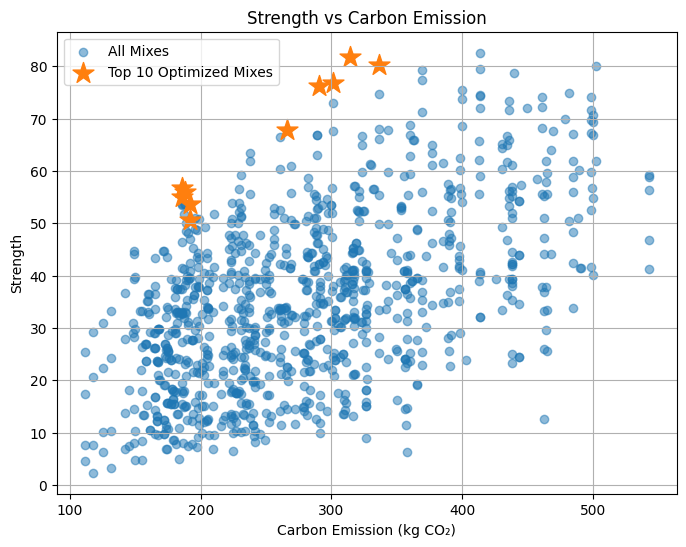

In [26]:
# Scatter Plot (Strength vs Carbon)
plt.figure(figsize=(8,6))

plt.scatter(
    df["Carbon_Emission_kgCO2"],
    df["Strength"],
    alpha=0.5,
    label="All Mixes"
)

plt.scatter(
    top10["Carbon_Emission_kgCO2"],
    top10["Strength"],
    marker="*",
    s=250,
    label="Top 10 Optimized Mixes"
)

plt.xlabel("Carbon Emission (kg CO₂)")

plt.ylabel("Strength")

plt.title("Strength vs Carbon Emission")

plt.legend()

plt.grid(True)

plt.show()

In [27]:
# Save Optimized Dataset
os.makedirs("../results", exist_ok=True)

optimized_df.to_csv(
    "../results/optimized_mix_recommendation.csv",
    index=False
)

print("Optimized dataset saved successfully!")

Optimized dataset saved successfully!


In [28]:
saved_df = pd.read_csv("../results/optimized_mix_recommendation.csv")

saved_df.head()

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Strength,Material_Cost_INR,Carbon_Emission_kgCO2,Strength_Norm,Cost_Norm,Carbon_Norm,Cost_Score,Carbon_Score,Optimization_Score
0,315.0,137.0,0.0,145.0,5.9,1130.0,745.0,28,81.75,5904.750,314.52450,0.989411,0.380794,0.470893,0.619206,0.529107,0.781784
1,275.0,180.0,120.0,162.0,10.4,830.0,765.0,28,76.24,6134.600,290.16560,0.920767,0.414947,0.414362,0.585053,0.585638,0.753056
2,190.0,190.0,0.0,228.0,0.0,932.0,670.0,365,53.69,3984.800,191.75440,0.639841,0.095512,0.185973,0.904488,0.814027,0.749549
3,286.3,200.9,0.0,144.7,11.2,1004.6,803.7,91,76.80,6396.705,301.27151,0.927744,0.453893,0.440136,0.546107,0.559864,0.740365
4,167.0,75.4,167.0,164.0,7.9,1007.3,770.1,100,56.81,4914.760,185.53990,0.678709,0.233694,0.171551,0.766306,0.828449,0.738044
